# Bitcoin 12 Years Price Analysis - Professional EDA

This notebook provides comprehensive exploratory data analysis of Bitcoin price data from September 2014 to January 2026, with focus on trading metrics, risk analysis, and market insights relevant to algorithmic trading strategies.

In [1]:
# Cell 1: Library Installation and Import Check
# This cell checks for required libraries and installs them if missing

import sys
import subprocess
import importlib

# Required libraries for professional data analysis
required_libraries = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'plotly': 'plotly',
    'scipy': 'scipy',
    'sklearn': 'scikit-learn',
    'statsmodels': 'statsmodels',
}

def check_and_install_library(lib_name, package_name=None):
    """Check if library is installed, install if not available"""
    if package_name is None:
        package_name = lib_name
    
    try:
        importlib.import_module(lib_name)
        print(f"✓ {lib_name} is already installed")
        return True
    except ImportError:
        print(f"✗ {lib_name} is not installed. Installing {package_name}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
            print(f"✓ Successfully installed {package_name}")
            return True
        except subprocess.CalledProcessError:
            print(f"✗ Failed to install {package_name}. Please install manually.")
            return False

# Check and install libraries
print("Checking required libraries...")
print("=" * 50)
missing_libs = []
for lib_name, package_name in required_libraries.items():
    if not check_and_install_library(lib_name, package_name):
        missing_libs.append(lib_name)

if missing_libs:
    print(f"\n⚠ Warning: The following libraries could not be installed: {', '.join(missing_libs)}")
    print("Please install them manually using: pip install <package_name>")
else:
    print("\n✓ All required libraries are available!")

print("=" * 50)

Checking required libraries...
✓ numpy is already installed
✓ pandas is already installed
✓ matplotlib is already installed
✓ seaborn is already installed
✓ plotly is already installed
✓ scipy is already installed
✓ sklearn is already installed
✓ statsmodels is already installed

✓ All required libraries are available!


In [2]:
# Cell 2: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from scipy import stats
from scipy.stats import norm
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options for professional output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.3.3
Matplotlib version: 3.9.4
Seaborn version: 0.13.2


In [3]:
# Cell 3: Load Data (Supports both Local and Kaggle environments)

import os

def load_bitcoin_data():
    """
    Load Bitcoin price data from either local device or Kaggle environment.
    Returns: pandas DataFrame
    """
    # Check if running in Kaggle environment
    kaggle_path = "/kaggle/input/bitcoin-12-years-price-january-2026/bitcoin.csv"
    local_path = "bitcoin.csv"
    
    if os.path.exists(kaggle_path):
        print(f"✓ Kaggle environment detected. Loading from: {kaggle_path}")
        df = pd.read_csv(kaggle_path)
    elif os.path.exists(local_path):
        print(f"✓ Local environment detected. Loading from: {local_path}")
        df = pd.read_csv(local_path)
    else:
        raise FileNotFoundError(
            f"Dataset not found! Checked:\n"
            f"  - Kaggle: {kaggle_path}\n"
            f"  - Local: {local_path}"
        )
    
    print(f"\n✓ Data loaded successfully!")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    
    return df

# Load the data
df = load_bitcoin_data()

✓ Local environment detected. Loading from: bitcoin.csv

✓ Data loaded successfully!
  Shape: (4134, 6)
  Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [4]:
# Cell 4: Data Preprocessing and Initial Exploration

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date to ensure chronological order
df = df.sort_values('Date').reset_index(drop=True)

# Basic data information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total Days: {len(df)}")
print(f"Total Years: {len(df) / 365.25:.2f}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")

print("\n" + "=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(df[['Close', 'High', 'Low', 'Open', 'Volume']].describe())

# Display first and last few rows
print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
print(df.tail())

DATASET OVERVIEW
Date Range: 2014-09-17 00:00:00 to 2026-01-10 00:00:00
Total Days: 4134
Total Years: 11.32

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Data Types:
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

DATA QUALITY CHECK
Missing Values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Duplicate Rows: 0

BASIC STATISTICS
            Close        High         Low        Open            Volume
count   4134.0000   4134.0000   4134.0000   4134.0000         4134.0000
mean   27003.8903  27524.7885  26411.3583  26983.1575  21664299789.6536
std    31769.7982  32299.1708  31181.5813  31757.8807  22877869294.8434
min      178.1030    211.7310    171.5100    176.8970      5914570.0000
25%     2717.3300   2787.3826   2646.2325   2709.4625   1318940000.0000
50%    10795.1455  11050.4810  10497.6787  10796.6187  171130312

In [5]:
# Cell 5: Feature Engineering - Trading Metrics

# Calculate daily returns (log returns for statistical properties)
df['Returns'] = df['Close'].pct_change()
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# Calculate price range (High - Low)
df['Price_Range'] = df['High'] - df['Low']
df['Price_Range_Pct'] = (df['Price_Range'] / df['Close']) * 100

# Calculate typical price (average of HLC)
df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3

# Calculate intraday return (Close - Open)
df['Intraday_Return'] = df['Close'] - df['Open']
df['Intraday_Return_Pct'] = (df['Intraday_Return'] / df['Open']) * 100

# Calculate volatility (rolling 30-day standard deviation of returns)
df['Volatility_30d'] = df['Returns'].rolling(window=30).std() * np.sqrt(252)  # Annualized

# Calculate rolling statistics
df['SMA_7'] = df['Close'].rolling(window=7).mean()
df['SMA_30'] = df['Close'].rolling(window=30).mean()
df['SMA_90'] = df['Close'].rolling(window=90).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

# Calculate RSI (Relative Strength Index)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Calculate MACD
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']

# Calculate Bollinger Bands
df['BB_Middle'] = df['Close'].rolling(window=20).mean()
bb_std = df['Close'].rolling(window=20).std()
df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)
df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)
df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']
df['BB_Position'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])

# Calculate volume indicators
df['Volume_SMA'] = df['Volume'].rolling(window=30).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA']

# Calculate drawdown
df['Cumulative_Return'] = (1 + df['Returns']).cumprod()
df['Running_Max'] = df['Cumulative_Return'].expanding().max()
df['Drawdown'] = (df['Cumulative_Return'] - df['Running_Max']) / df['Running_Max']
df['Drawdown_Pct'] = df['Drawdown'] * 100

# Year, Month, Day extraction for time-based analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

print("✓ Feature engineering completed!")
print(f"Total features: {len(df.columns)}")
print(f"\nNew features created:")
new_features = [col for col in df.columns if col not in ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']]
print(f"  {', '.join(new_features[:10])}...")
print(f"  (Total {len(new_features)} new features)")

✓ Feature engineering completed!
Total features: 40

New features created:
  Returns, Log_Returns, Price_Range, Price_Range_Pct, Typical_Price, Intraday_Return, Intraday_Return_Pct, Volatility_30d, SMA_7, SMA_30...
  (Total 34 new features)


## 1. Price Evolution Analysis

In [6]:
# Cell 6: Price Evolution Over Time - Interactive Plotly Visualization

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    subplot_titles=('Bitcoin Price Evolution (2014-2026)', 'Trading Volume'),
    row_heights=[0.7, 0.3]
)

# Price chart with candlestick
fig.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['Close'],
        mode='lines',
        name='Close Price',
        line=dict(color='#1f77b4', width=2),
        hovertemplate='Date: %{x}<br>Price: $%{y:,.2f}<extra></extra>'
    ),
    row=1, col=1
)

# Add moving averages
fig.add_trace(
    go.Scatter(x=df['Date'], y=df['SMA_30'], name='SMA 30', 
               line=dict(color='orange', width=1, dash='dash')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=df['Date'], y=df['SMA_200'], name='SMA 200', 
               line=dict(color='red', width=1, dash='dash')),
    row=1, col=1
)

# Volume chart
fig.add_trace(
    go.Bar(
        x=df['Date'],
        y=df['Volume'],
        name='Volume',
        marker_color='rgba(158,202,225,0.5)',
        hovertemplate='Date: %{x}<br>Volume: %{y:,.0f}<extra></extra>'
    ),
    row=2, col=1
)

fig.update_layout(
    title_text='Bitcoin Price and Volume Analysis (2014-2026)',
    height=800,
    hovermode='x unified',
    template='plotly_dark',
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Price (USD)", row=1, col=1)
fig.update_yaxes(title_text="Volume", row=2, col=1)

fig.show()

In [7]:
# Cell 7: Log-Scale Price Chart (Better for visualizing long-term trends)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['Close'],
    mode='lines',
    name='Close Price (Log Scale)',
    line=dict(color='#00D9FF', width=2),
    hovertemplate='Date: %{x}<br>Price: $%{y:,.2f}<extra></extra>'
))

fig.update_layout(
    title='Bitcoin Price Evolution (Log Scale) - 2014-2026',
    xaxis_title='Date',
    yaxis_title='Price (USD) - Log Scale',
    yaxis_type="log",
    height=600,
    template='plotly_dark',
    hovermode='x unified'
)

fig.show()

# Key price milestones
print("\n" + "=" * 60)
print("KEY PRICE MILESTONES")
print("=" * 60)
print(f"Minimum Price: ${df['Close'].min():,.2f} on {df.loc[df['Close'].idxmin(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Maximum Price: ${df['Close'].max():,.2f} on {df.loc[df['Close'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Starting Price: ${df['Close'].iloc[0]:,.2f}")
print(f"Ending Price: ${df['Close'].iloc[-1]:,.2f}")
print(f"Total Return: {((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100:.2f}%")
print(f"Annualized Return: {((df['Close'].iloc[-1] / df['Close'].iloc[0]) ** (365.25 / len(df)) - 1) * 100:.2f}%")


KEY PRICE MILESTONES
Minimum Price: $178.10 on 2015-01-14
Maximum Price: $124,752.53 on 2025-10-06
Starting Price: $457.33
Ending Price: $90,386.65
Total Return: 19663.81%
Annualized Return: 59.53%


## 2. Returns Analysis

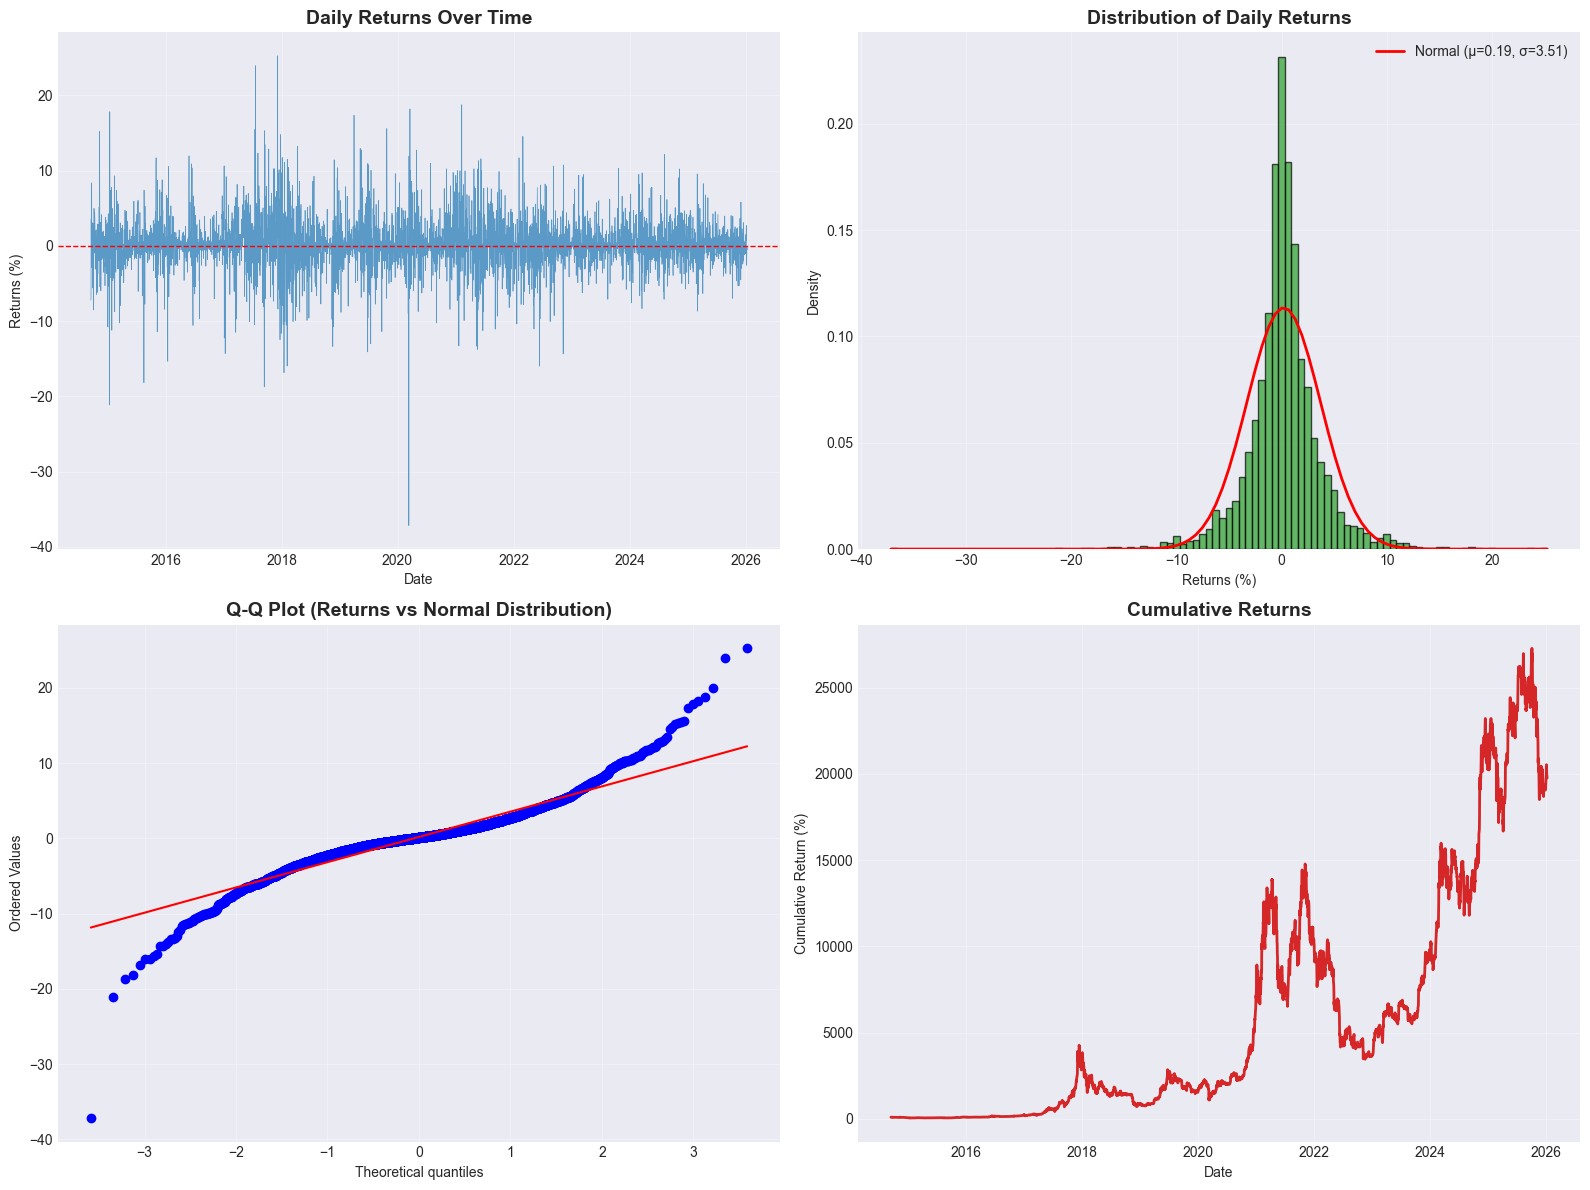


RETURNS STATISTICAL SUMMARY
count   413300.0000
mean         0.1902
std          3.5143
min        -37.1695
25%         -1.2422
50%          0.1206
75%          1.6051
max         25.2472
Name: Returns, dtype: float64

Skewness: -0.1011
Kurtosis: 7.8909
Shapiro-Wilk Normality Test p-value: 0.000000


In [8]:
# Cell 8: Returns Distribution Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time series of returns
axes[0, 0].plot(df['Date'], df['Returns'] * 100, linewidth=0.5, alpha=0.7, color='#1f77b4')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[0, 0].set_title('Daily Returns Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Returns (%)')
axes[0, 0].grid(True, alpha=0.3)

# Histogram of returns
returns_clean = df['Returns'].dropna() * 100
axes[0, 1].hist(returns_clean, bins=100, density=True, alpha=0.7, color='#2ca02c', edgecolor='black')
# Overlay normal distribution
mu, sigma = returns_clean.mean(), returns_clean.std()
x = np.linspace(returns_clean.min(), returns_clean.max(), 100)
axes[0, 1].plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'Normal (μ={mu:.2f}, σ={sigma:.2f})')
axes[0, 1].set_title('Distribution of Daily Returns', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Returns (%)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats as scipy_stats
scipy_stats.probplot(returns_clean, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Returns vs Normal Distribution)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Cumulative returns
axes[1, 1].plot(df['Date'], df['Cumulative_Return'] * 100, linewidth=2, color='#d62728')
axes[1, 1].set_title('Cumulative Returns', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Cumulative Return (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary of returns
print("\n" + "=" * 60)
print("RETURNS STATISTICAL SUMMARY")
print("=" * 60)
returns_stats = df['Returns'].describe()
print(returns_stats * 100)  # Convert to percentage
print(f"\nSkewness: {df['Returns'].skew():.4f}")
print(f"Kurtosis: {df['Returns'].kurtosis():.4f}")
print(f"Shapiro-Wilk Normality Test p-value: {scipy_stats.shapiro(returns_clean[:5000])[1]:.6f}")

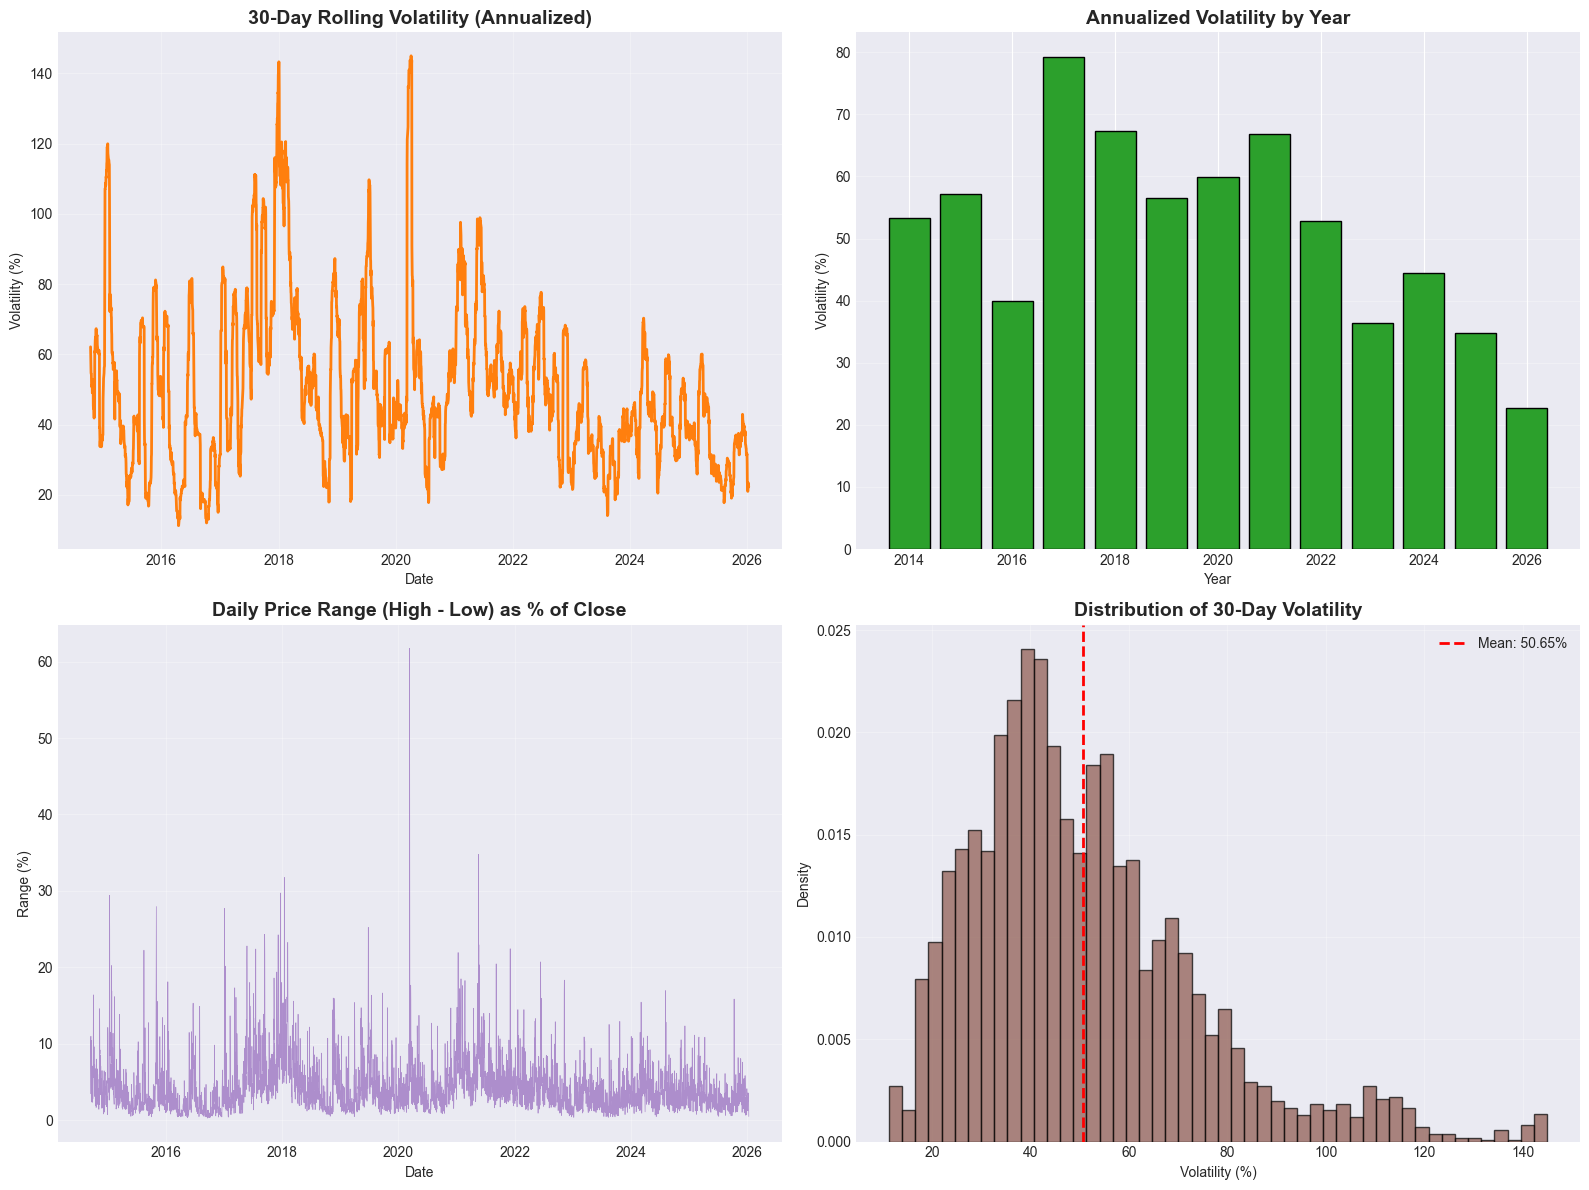


VOLATILITY SUMMARY
Mean 30-Day Volatility: 50.65%
Median 30-Day Volatility: 46.01%
Max 30-Day Volatility: 144.98%
Min 30-Day Volatility: 11.26%

Overall Daily Volatility: 55.79% (annualized)


In [9]:
# Cell 9: Volatility Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Rolling volatility
axes[0, 0].plot(df['Date'], df['Volatility_30d'] * 100, linewidth=2, color='#ff7f0e')
axes[0, 0].set_title('30-Day Rolling Volatility (Annualized)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Volatility (%)')
axes[0, 0].grid(True, alpha=0.3)

# Volatility by year
volatility_by_year = df.groupby('Year')['Returns'].std() * np.sqrt(252) * 100
axes[0, 1].bar(volatility_by_year.index, volatility_by_year.values, color='#2ca02c', edgecolor='black')
axes[0, 1].set_title('Annualized Volatility by Year', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Volatility (%)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Price range percentage
axes[1, 0].plot(df['Date'], df['Price_Range_Pct'], linewidth=0.5, alpha=0.7, color='#9467bd')
axes[1, 0].set_title('Daily Price Range (High - Low) as % of Close', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Range (%)')
axes[1, 0].grid(True, alpha=0.3)

# Volatility distribution
volatility_clean = df['Volatility_30d'].dropna() * 100
axes[1, 1].hist(volatility_clean, bins=50, density=True, alpha=0.7, color='#8c564b', edgecolor='black')
axes[1, 1].axvline(volatility_clean.mean(), color='r', linestyle='--', linewidth=2, 
                   label=f'Mean: {volatility_clean.mean():.2f}%')
axes[1, 1].set_title('Distribution of 30-Day Volatility', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Volatility (%)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("VOLATILITY SUMMARY")
print("=" * 60)
print(f"Mean 30-Day Volatility: {df['Volatility_30d'].mean() * 100:.2f}%")
print(f"Median 30-Day Volatility: {df['Volatility_30d'].median() * 100:.2f}%")
print(f"Max 30-Day Volatility: {df['Volatility_30d'].max() * 100:.2f}%")
print(f"Min 30-Day Volatility: {df['Volatility_30d'].min() * 100:.2f}%")
print(f"\nOverall Daily Volatility: {df['Returns'].std() * np.sqrt(252) * 100:.2f}% (annualized)")

## 3. Risk Metrics

RISK METRICS SUMMARY
Annualized Return        :      47.93%
Annualized Volatility    :      55.79%
Sharpe Ratio             :     0.8591
VaR (95%)                :      -5.32%
VaR (99%)                :     -10.04%
CVaR (95%)               :      -8.21%
CVaR (99%)               :     -13.23%
Maximum Drawdown         :     -83.40%
Calmar Ratio             :     0.5747


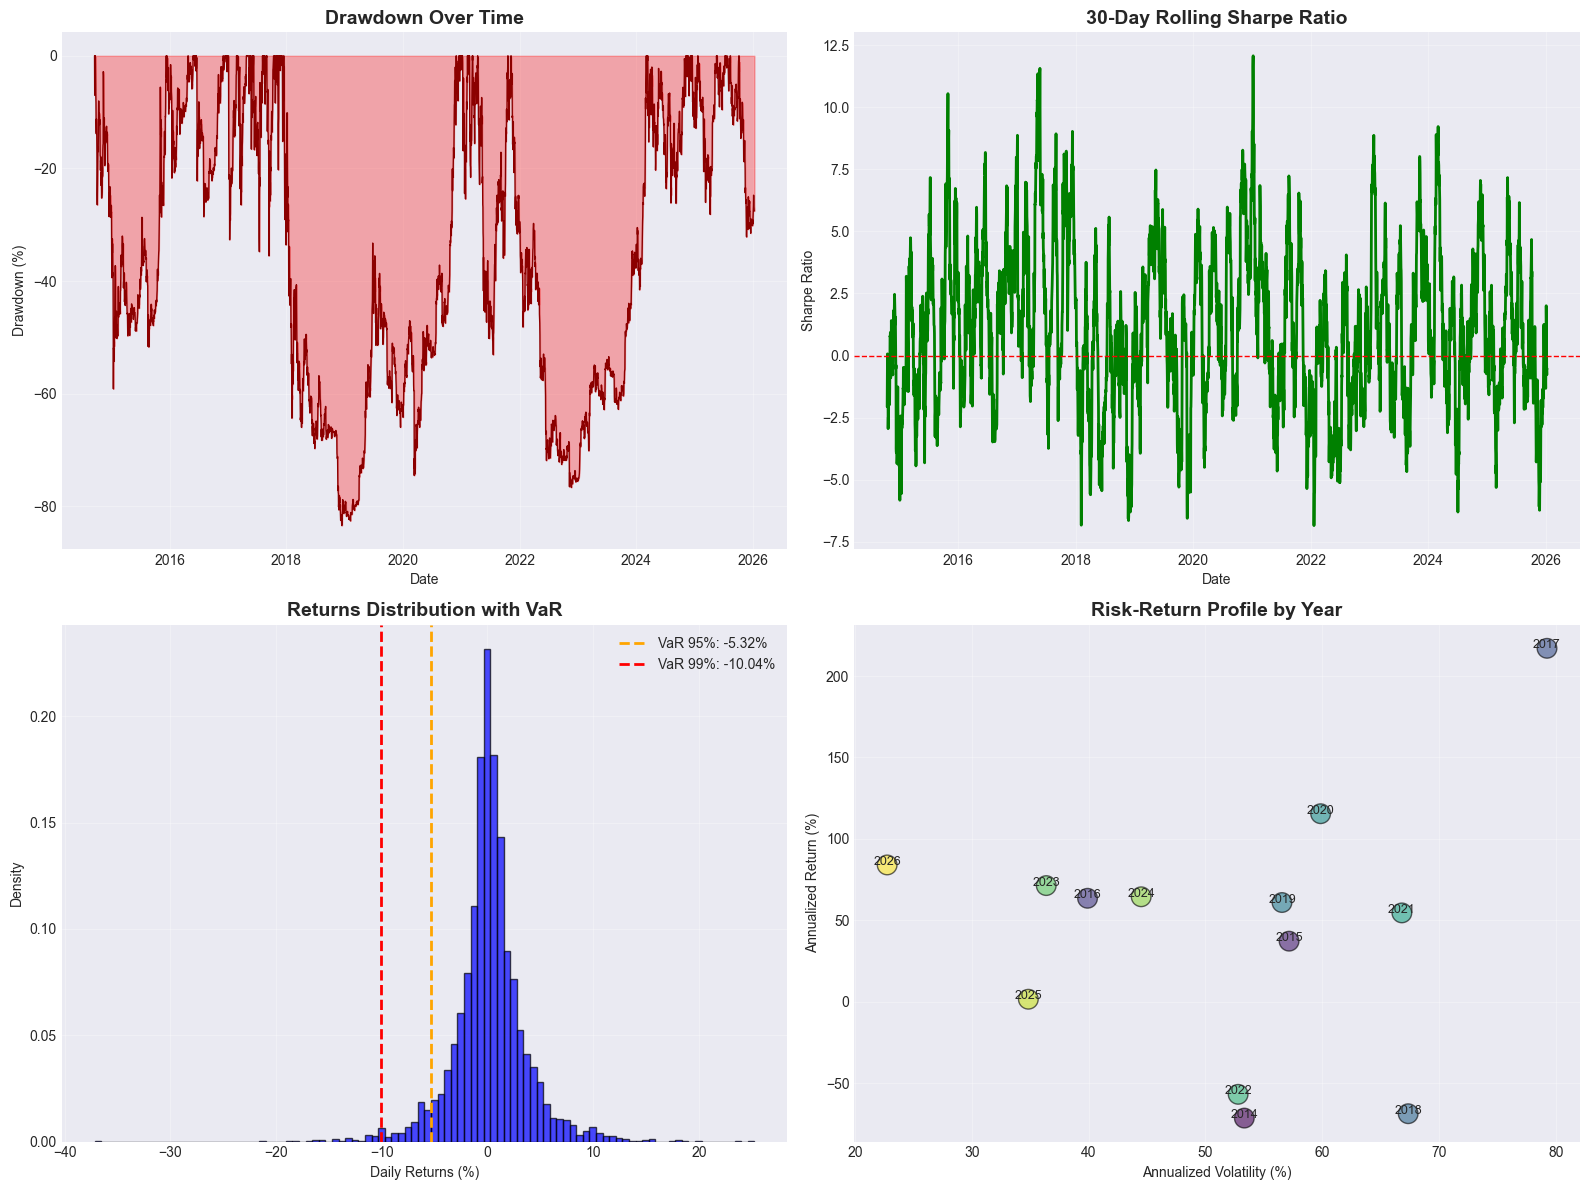

In [10]:
# Cell 10: Risk Metrics - VaR, CVaR, Sharpe Ratio, Maximum Drawdown

from scipy.stats import norm

def calculate_risk_metrics(returns):
    """Calculate comprehensive risk metrics"""
    returns_annual = returns.mean() * 252
    volatility_annual = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio (assuming risk-free rate = 0)
    sharpe_ratio = returns_annual / volatility_annual if volatility_annual != 0 else 0
    
    # Value at Risk (VaR) - 95% and 99% confidence levels
    var_95 = np.percentile(returns, 5)
    var_99 = np.percentile(returns, 1)
    
    # Conditional VaR (CVaR) - Expected shortfall
    cvar_95 = returns[returns <= var_95].mean()
    cvar_99 = returns[returns <= var_99].mean()
    
    # Maximum Drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Calmar Ratio (Annual Return / Max Drawdown)
    calmar_ratio = returns_annual / abs(max_drawdown) if max_drawdown != 0 else 0
    
    return {
        'Annualized Return': returns_annual * 100,
        'Annualized Volatility': volatility_annual * 100,
        'Sharpe Ratio': sharpe_ratio,
        'VaR (95%)': var_95 * 100,
        'VaR (99%)': var_99 * 100,
        'CVaR (95%)': cvar_95 * 100,
        'CVaR (99%)': cvar_99 * 100,
        'Maximum Drawdown': max_drawdown * 100,
        'Calmar Ratio': calmar_ratio
    }

# Calculate overall risk metrics
overall_metrics = calculate_risk_metrics(df['Returns'].dropna())

print("=" * 60)
print("RISK METRICS SUMMARY")
print("=" * 60)
for metric, value in overall_metrics.items():
    if 'Ratio' in metric:
        print(f"{metric:25s}: {value:>10.4f}")
    elif 'Drawdown' in metric:
        print(f"{metric:25s}: {value:>10.2f}%")
    else:
        print(f"{metric:25s}: {value:>10.2f}%")

# Calculate rolling Sharpe Ratio (30-day window)
df['Sharpe_30d'] = (df['Returns'].rolling(30).mean() * 252) / (df['Returns'].rolling(30).std() * np.sqrt(252))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Drawdown chart
axes[0, 0].fill_between(df['Date'], df['Drawdown_Pct'], 0, alpha=0.3, color='red')
axes[0, 0].plot(df['Date'], df['Drawdown_Pct'], linewidth=1, color='darkred')
axes[0, 0].set_title('Drawdown Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Drawdown (%)')
axes[0, 0].grid(True, alpha=0.3)

# Rolling Sharpe Ratio
axes[0, 1].plot(df['Date'], df['Sharpe_30d'], linewidth=2, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[0, 1].set_title('30-Day Rolling Sharpe Ratio', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].grid(True, alpha=0.3)

# VaR Visualization
returns_clean = df['Returns'].dropna() * 100
axes[1, 0].hist(returns_clean, bins=100, density=True, alpha=0.7, color='blue', edgecolor='black')
var_95 = np.percentile(returns_clean, 5)
var_99 = np.percentile(returns_clean, 1)
axes[1, 0].axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'VaR 95%: {var_95:.2f}%')
axes[1, 0].axvline(var_99, color='red', linestyle='--', linewidth=2, label=f'VaR 99%: {var_99:.2f}%')
axes[1, 0].set_title('Returns Distribution with VaR', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Daily Returns (%)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Risk-Return scatter (by year)
yearly_returns = df.groupby('Year')['Returns'].agg(['mean', 'std'])
yearly_returns['Annual_Return'] = yearly_returns['mean'] * 252 * 100
yearly_returns['Annual_Vol'] = yearly_returns['std'] * np.sqrt(252) * 100
axes[1, 1].scatter(yearly_returns['Annual_Vol'], yearly_returns['Annual_Return'], 
                   s=200, alpha=0.6, c=yearly_returns.index, cmap='viridis', edgecolors='black')
for year in yearly_returns.index:
    axes[1, 1].annotate(str(year), 
                       (yearly_returns.loc[year, 'Annual_Vol'], yearly_returns.loc[year, 'Annual_Return']),
                       fontsize=9, ha='center')
axes[1, 1].set_title('Risk-Return Profile by Year', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Annualized Volatility (%)')
axes[1, 1].set_ylabel('Annualized Return (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Technical Indicators Analysis

In [11]:
# Cell 11: Technical Indicators - RSI, MACD, Bollinger Bands

fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.02,
    subplot_titles=('Price with Moving Averages', 'RSI (Relative Strength Index)', 
                    'MACD', 'Bollinger Bands'),
    row_heights=[0.4, 0.2, 0.2, 0.2]
)

# Price with MAs
fig.add_trace(go.Scatter(x=df['Date'], y=df['Close'], name='Close', 
                         line=dict(color='white', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=df['Date'], y=df['SMA_30'], name='SMA 30', 
                         line=dict(color='orange', width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=df['Date'], y=df['SMA_200'], name='SMA 200', 
                         line=dict(color='red', width=1)), row=1, col=1)

# RSI
fig.add_trace(go.Scatter(x=df['Date'], y=df['RSI'], name='RSI', 
                         line=dict(color='purple', width=2)), row=2, col=1)
fig.add_hline(y=70, line_dash="dash", line_color="red", row=2, col=1)
fig.add_hline(y=30, line_dash="dash", line_color="green", row=2, col=1)

# MACD
fig.add_trace(go.Scatter(x=df['Date'], y=df['MACD'], name='MACD', 
                         line=dict(color='blue', width=2)), row=3, col=1)
fig.add_trace(go.Scatter(x=df['Date'], y=df['MACD_Signal'], name='Signal', 
                         line=dict(color='red', width=1)), row=3, col=1)
fig.add_trace(go.Bar(x=df['Date'], y=df['MACD_Histogram'], name='Histogram', 
                     marker_color='gray'), row=3, col=1)

# Bollinger Bands
fig.add_trace(go.Scatter(x=df['Date'], y=df['BB_Upper'], name='BB Upper', 
                         line=dict(color='red', width=1, dash='dash'), fill=None), row=4, col=1)
fig.add_trace(go.Scatter(x=df['Date'], y=df['BB_Middle'], name='BB Middle', 
                         line=dict(color='blue', width=1)), row=4, col=1)
fig.add_trace(go.Scatter(x=df['Date'], y=df['BB_Lower'], name='BB Lower', 
                         line=dict(color='red', width=1, dash='dash'), fill='tonexty', 
                         fillcolor='rgba(255,0,0,0.1)'), row=4, col=1)
fig.add_trace(go.Scatter(x=df['Date'], y=df['Close'], name='Close', 
                         line=dict(color='white', width=1)), row=4, col=1)

fig.update_layout(
    title_text='Technical Indicators Analysis',
    height=1000,
    template='plotly_dark',
    showlegend=True,
    hovermode='x unified'
)

fig.update_yaxes(title_text="Price (USD)", row=1, col=1)
fig.update_yaxes(title_text="RSI", row=2, col=1, range=[0, 100])
fig.update_yaxes(title_text="MACD", row=3, col=1)
fig.update_yaxes(title_text="Price (USD)", row=4, col=1)

fig.show()

# Current indicator values
print("\n" + "=" * 60)
print("CURRENT TECHNICAL INDICATOR VALUES (Last Trading Day)")
print("=" * 60)
print(f"RSI: {df['RSI'].iloc[-1]:.2f}")
print(f"MACD: {df['MACD'].iloc[-1]:.2f}")
print(f"MACD Signal: {df['MACD_Signal'].iloc[-1]:.2f}")
print(f"Bollinger Position: {df['BB_Position'].iloc[-1]:.2%}")
print(f"Price vs SMA 30: {((df['Close'].iloc[-1] / df['SMA_30'].iloc[-1]) - 1) * 100:.2f}%")
print(f"Price vs SMA 200: {((df['Close'].iloc[-1] / df['SMA_200'].iloc[-1]) - 1) * 100:.2f}%")


CURRENT TECHNICAL INDICATOR VALUES (Last Trading Day)
RSI: 60.08
MACD: 492.27
MACD Signal: 203.12
Bollinger Position: 61.46%
Price vs SMA 30: 1.63%
Price vs SMA 200: -15.00%


## 5. Volume Analysis

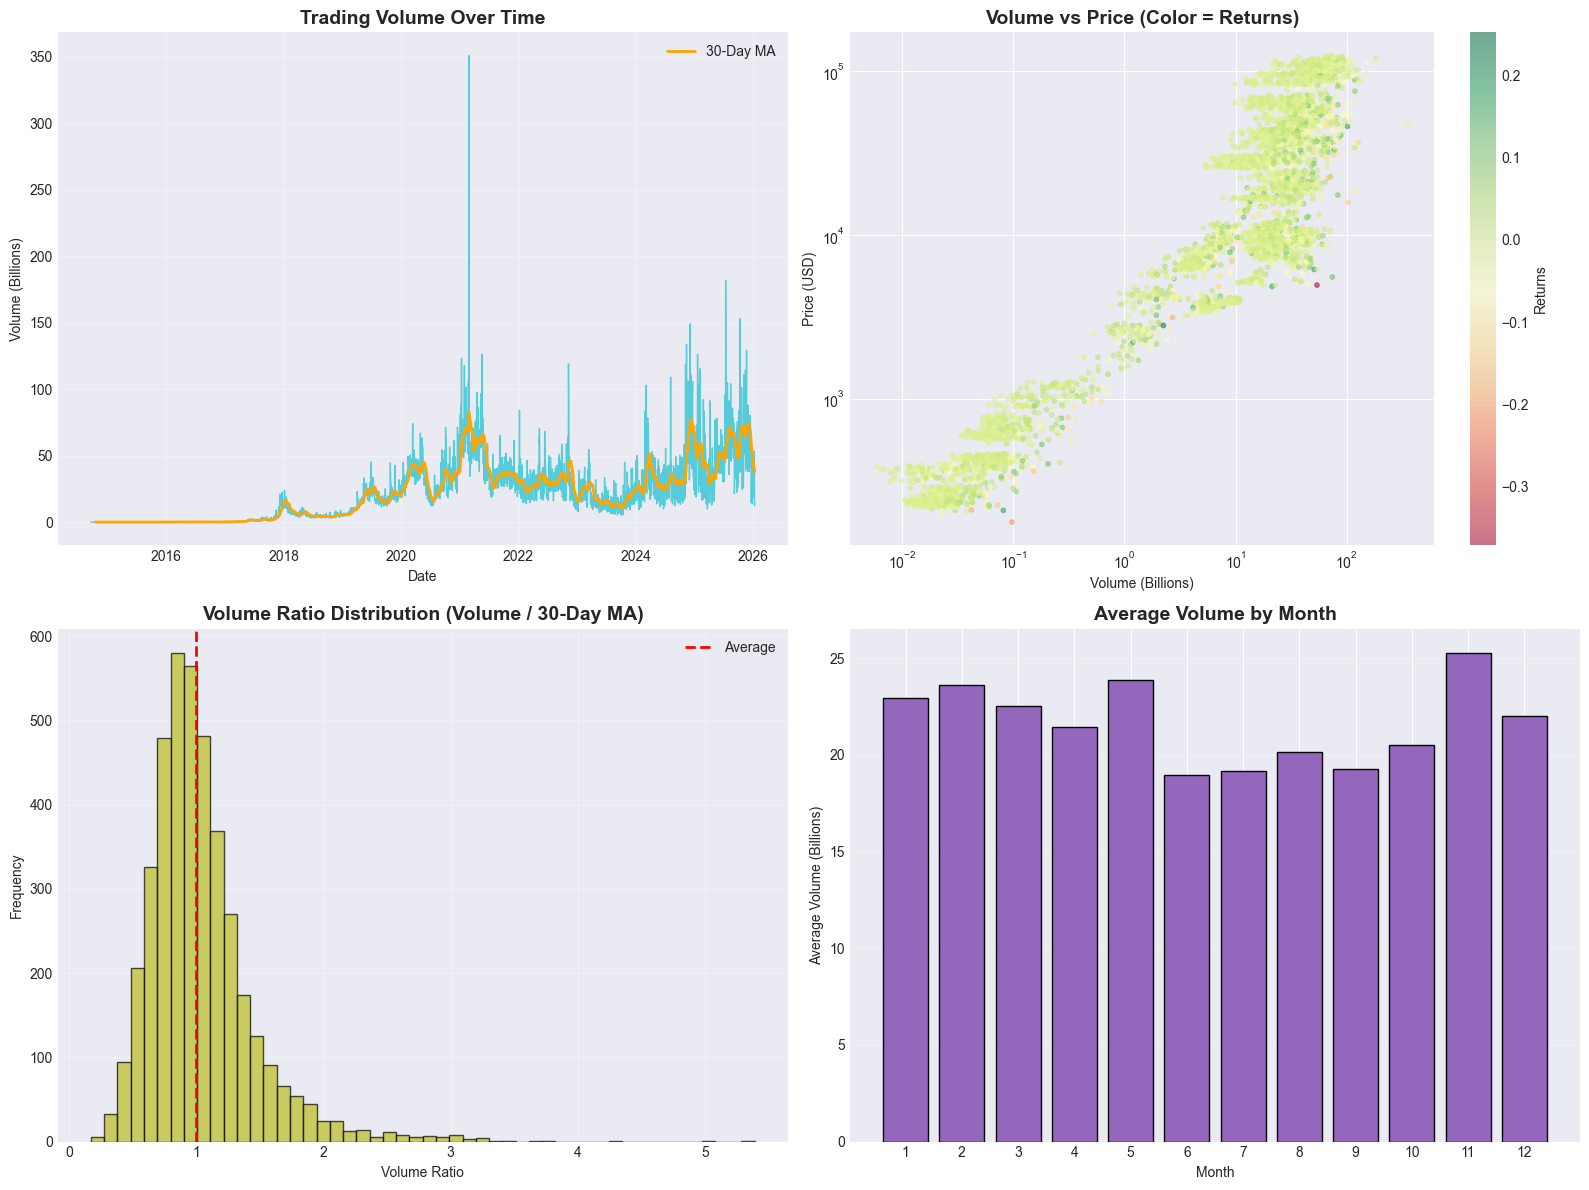


VOLUME STATISTICS
Average Daily Volume: 21.66 Billion
Median Daily Volume: 17.11 Billion
Max Daily Volume: 350.97 Billion
Min Daily Volume: 0.01 Billion

Days with Volume > 2x Average: 126
Days with Volume < 0.5x Average: 157

Correlation (Volume vs Returns): -0.0146
Correlation (Volume vs |Returns|): 0.1211


In [12]:
# Cell 12: Volume Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Volume over time
axes[0, 0].plot(df['Date'], df['Volume'] / 1e9, linewidth=1, alpha=0.7, color='#17becf')
axes[0, 0].plot(df['Date'], df['Volume_SMA'] / 1e9, linewidth=2, color='orange', label='30-Day MA')
axes[0, 0].set_title('Trading Volume Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Volume (Billions)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Volume vs Price
scatter = axes[0, 1].scatter(df['Volume'] / 1e9, df['Close'], 
                            c=df['Returns'], cmap='RdYlGn', alpha=0.5, s=10)
axes[0, 1].set_title('Volume vs Price (Color = Returns)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Volume (Billions)')
axes[0, 1].set_ylabel('Price (USD)')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
plt.colorbar(scatter, ax=axes[0, 1], label='Returns')

# Volume ratio distribution
volume_ratio_clean = df['Volume_Ratio'].dropna()
axes[1, 0].hist(volume_ratio_clean, bins=50, alpha=0.7, color='#bcbd22', edgecolor='black')
axes[1, 0].axvline(1, color='r', linestyle='--', linewidth=2, label='Average')
axes[1, 0].set_title('Volume Ratio Distribution (Volume / 30-Day MA)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Volume Ratio')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Average volume by month
avg_volume_by_month = df.groupby('Month')['Volume'].mean() / 1e9
axes[1, 1].bar(range(1, 13), avg_volume_by_month.values, color='#9467bd', edgecolor='black')
axes[1, 1].set_title('Average Volume by Month', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Volume (Billions)')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Volume statistics
print("\n" + "=" * 60)
print("VOLUME STATISTICS")
print("=" * 60)
print(f"Average Daily Volume: {df['Volume'].mean() / 1e9:.2f} Billion")
print(f"Median Daily Volume: {df['Volume'].median() / 1e9:.2f} Billion")
print(f"Max Daily Volume: {df['Volume'].max() / 1e9:.2f} Billion")
print(f"Min Daily Volume: {df['Volume'].min() / 1e9:.2f} Billion")
print(f"\nDays with Volume > 2x Average: {(df['Volume_Ratio'] > 2).sum()}")
print(f"Days with Volume < 0.5x Average: {(df['Volume_Ratio'] < 0.5).sum()}")

# Correlation between volume and absolute returns
volume_abs_return_corr = df[['Volume', 'Returns']].corr().iloc[0, 1]
print(f"\nCorrelation (Volume vs Returns): {volume_abs_return_corr:.4f}")
volume_abs_return_corr = df['Volume'].corr(df['Returns'].abs())
print(f"Correlation (Volume vs |Returns|): {volume_abs_return_corr:.4f}")

## 6. Market Regime Analysis

MARKET REGIME CHANGES
Total regime changes: 76

Current Regime: Bear

STATISTICS BY MARKET REGIME
        Returns              Volatility_30d           Volume
           mean    std count           mean             mean
Regime                                                      
Bear    -0.0017 0.0341  1421         0.5082 21226665585.2041
Bull     0.0042 0.0349  2514         0.4960 23624405368.9025
Neutral -0.0020 0.0425   198         0.6475    26977067.4975


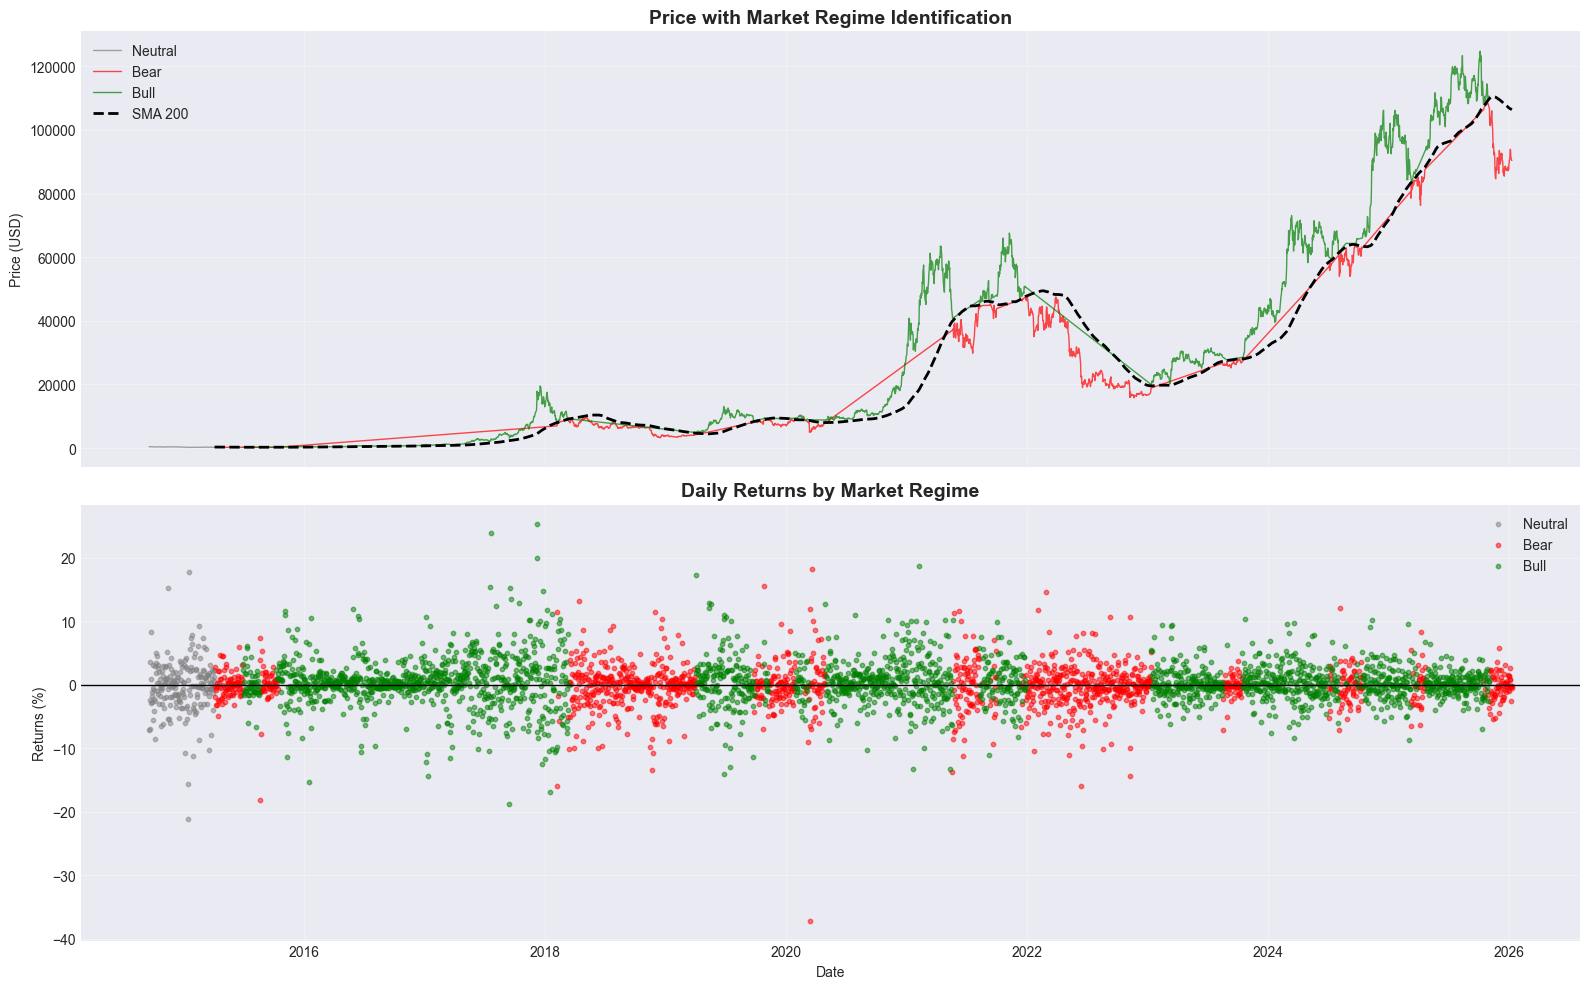

In [13]:
# Cell 13: Market Regime Detection (Bull vs Bear Markets)

# Define market regimes based on moving averages
df['Regime'] = 'Neutral'
df.loc[df['Close'] > df['SMA_200'], 'Regime'] = 'Bull'
df.loc[df['Close'] < df['SMA_200'], 'Regime'] = 'Bear'

# Identify bull and bear periods
regime_changes = df[df['Regime'] != df['Regime'].shift(1)]
print("=" * 60)
print("MARKET REGIME CHANGES")
print("=" * 60)
print(f"Total regime changes: {len(regime_changes)}")
print(f"\nCurrent Regime: {df['Regime'].iloc[-1]}")

# Calculate statistics by regime
regime_stats = df.groupby('Regime').agg({
    'Returns': ['mean', 'std', 'count'],
    'Volatility_30d': 'mean',
    'Volume': 'mean'
}).round(4)

print("\n" + "=" * 60)
print("STATISTICS BY MARKET REGIME")
print("=" * 60)
print(regime_stats)

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Price with regime coloring
colors = {'Bull': 'green', 'Bear': 'red', 'Neutral': 'gray'}
for regime in df['Regime'].unique():
    mask = df['Regime'] == regime
    axes[0].plot(df.loc[mask, 'Date'], df.loc[mask, 'Close'], 
                color=colors[regime], alpha=0.7, linewidth=1, label=regime)

axes[0].plot(df['Date'], df['SMA_200'], 'black', linewidth=2, label='SMA 200', linestyle='--')
axes[0].set_title('Price with Market Regime Identification', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Returns by regime
for regime in df['Regime'].unique():
    mask = df['Regime'] == regime
    axes[1].scatter(df.loc[mask, 'Date'], df.loc[mask, 'Returns'] * 100, 
                   color=colors[regime], alpha=0.5, s=10, label=regime)

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_title('Daily Returns by Market Regime', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Returns (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Seasonality Analysis

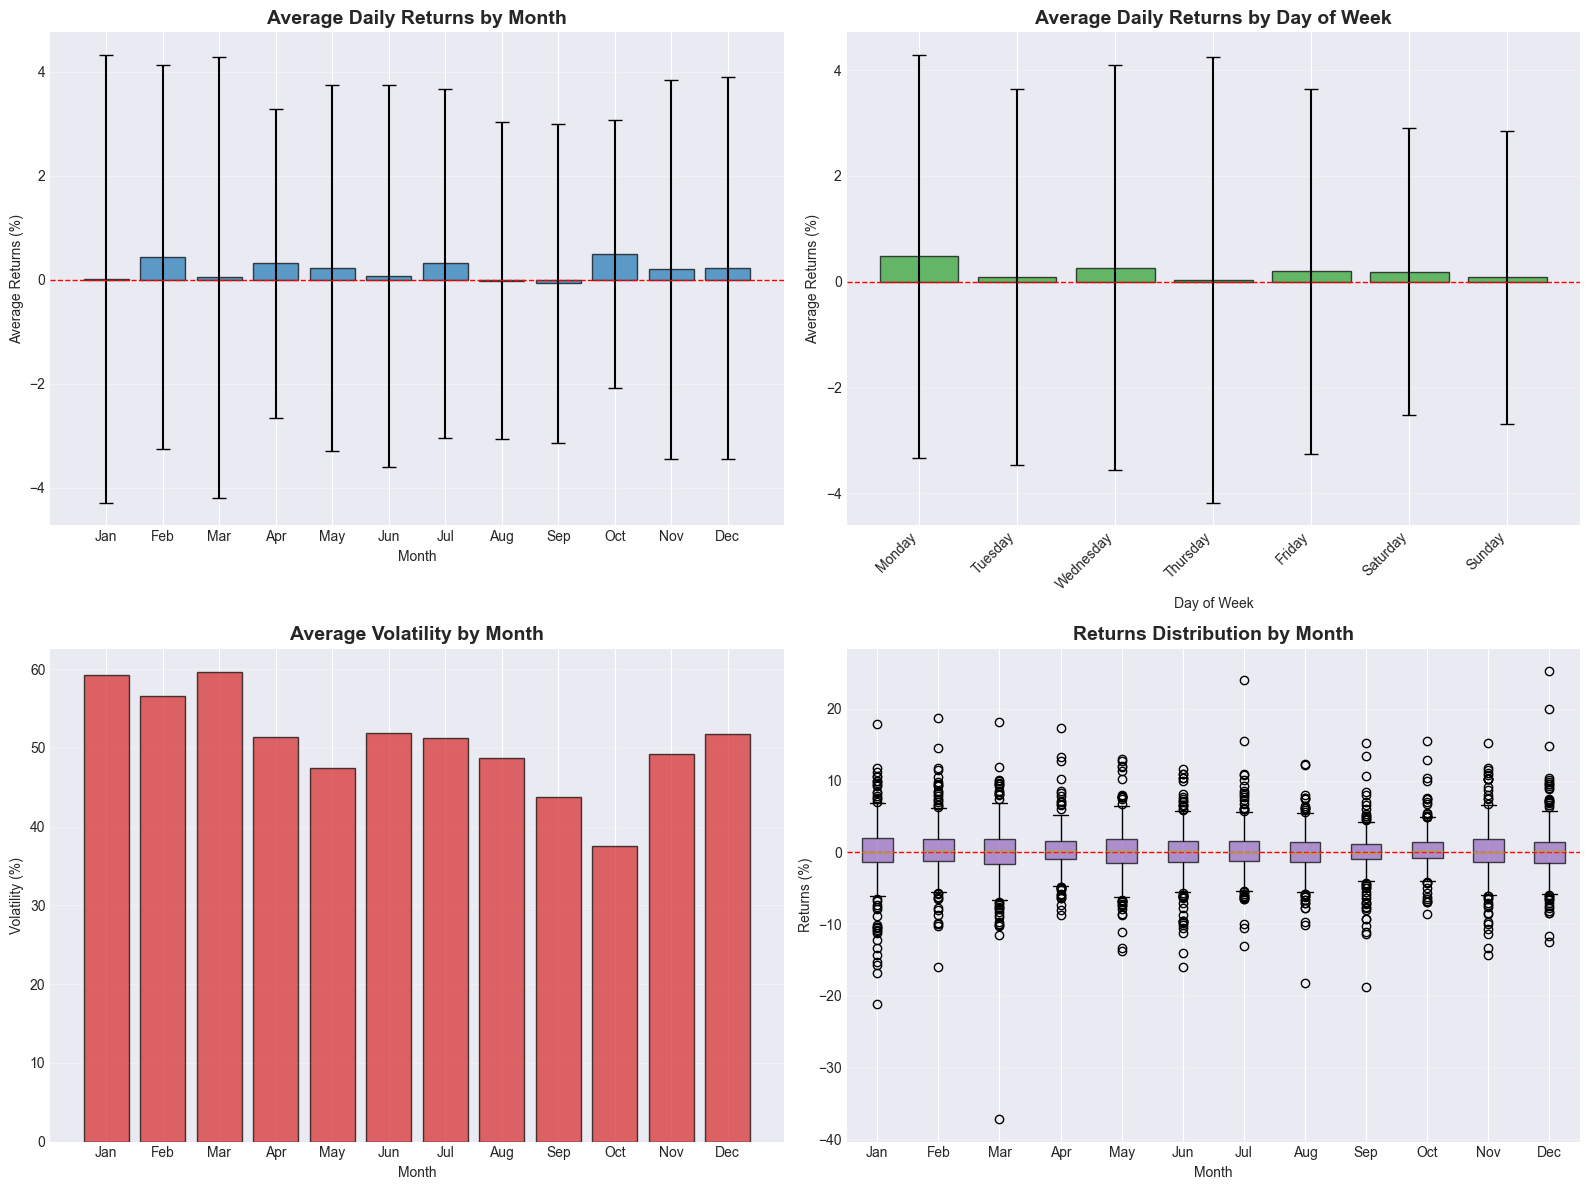


SEASONALITY SUMMARY
Best Month (Avg Return): Month 10 (0.489%)
Worst Month (Avg Return): Month 9 (-0.068%)
Best Day of Week: Monday (0.481%)
Worst Day of Week: Thursday (0.033%)


In [14]:
# Cell 14: Seasonality Analysis - Monthly and Weekly Patterns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Average returns by month
monthly_returns = df.groupby('Month')['Returns'].mean() * 100
monthly_std = df.groupby('Month')['Returns'].std() * 100
axes[0, 0].bar(range(1, 13), monthly_returns.values, yerr=monthly_std.values, 
               color='#1f77b4', edgecolor='black', capsize=5, alpha=0.7)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[0, 0].set_title('Average Daily Returns by Month', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Average Returns (%)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Average returns by day of week
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_returns = df.groupby('DayOfWeek')['Returns'].mean() * 100
dow_std = df.groupby('DayOfWeek')['Returns'].std() * 100
axes[0, 1].bar(range(7), dow_returns.values, yerr=dow_std.values, 
               color='#2ca02c', edgecolor='black', capsize=5, alpha=0.7)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[0, 1].set_title('Average Daily Returns by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average Returns (%)')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(dow_names, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Volatility by month
monthly_vol = df.groupby('Month')['Volatility_30d'].mean() * 100
axes[1, 0].bar(range(1, 13), monthly_vol.values, color='#d62728', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Average Volatility by Month', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Volatility (%)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Returns distribution by month (box plot)
monthly_returns_data = [df[df['Month'] == m]['Returns'].dropna() * 100 for m in range(1, 13)]
bp = axes[1, 1].boxplot(monthly_returns_data, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
                        patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#9467bd')
    patch.set_alpha(0.7)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[1, 1].set_title('Returns Distribution by Month', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Returns (%)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SEASONALITY SUMMARY")
print("=" * 60)
print(f"Best Month (Avg Return): Month {monthly_returns.idxmax()} ({monthly_returns.max():.3f}%)")
print(f"Worst Month (Avg Return): Month {monthly_returns.idxmin()} ({monthly_returns.min():.3f}%)")
print(f"Best Day of Week: {dow_names[dow_returns.idxmax()]} ({dow_returns.max():.3f}%)")
print(f"Worst Day of Week: {dow_names[dow_returns.idxmin()]} ({dow_returns.min():.3f}%)")

## 8. Correlation Analysis

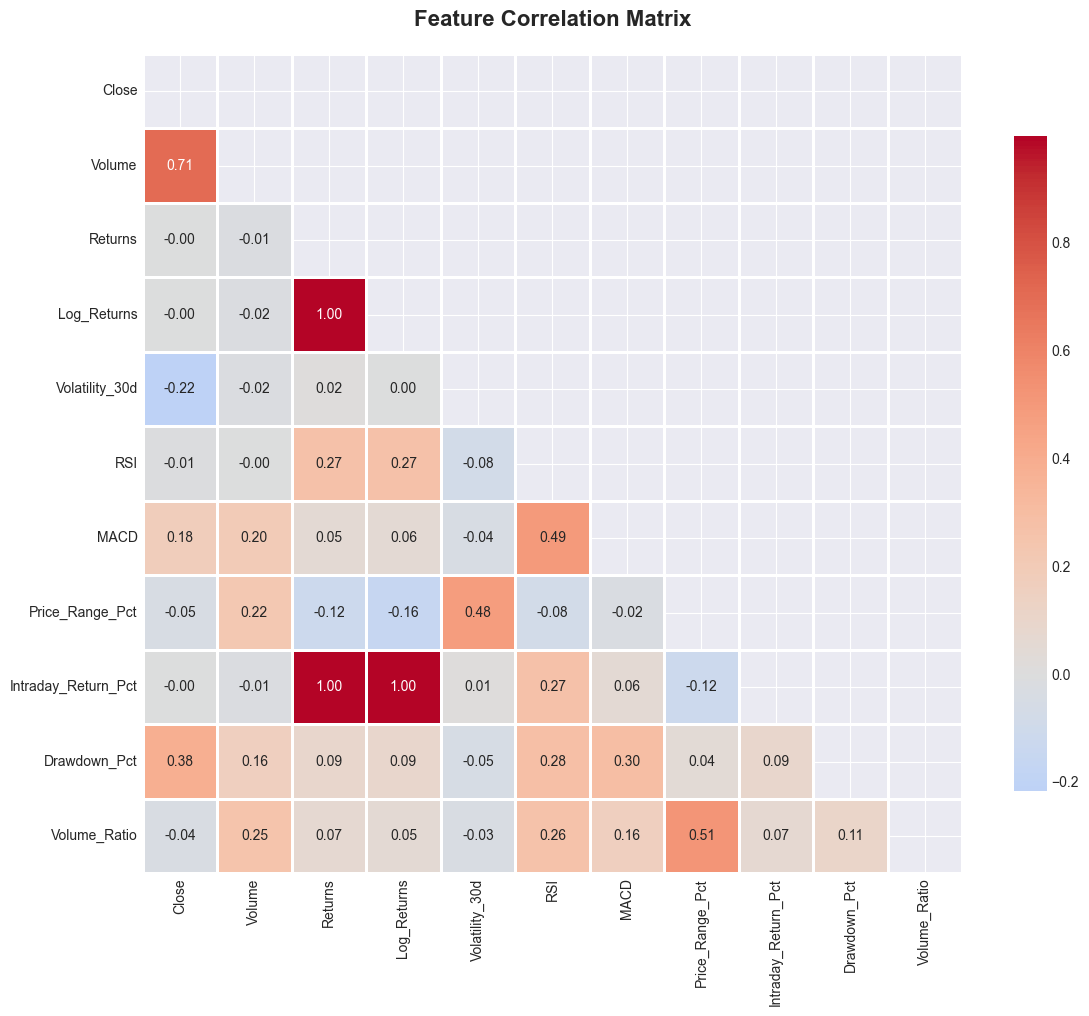


TOP POSITIVE CORRELATIONS
Returns vs Intraday_Return_Pct: 0.9985
Returns vs Log_Returns: 0.9982
Log_Returns vs Intraday_Return_Pct: 0.9967
Close vs Volume: 0.7055
Price_Range_Pct vs Volume_Ratio: 0.5142
RSI vs MACD: 0.4905
Volatility_30d vs Price_Range_Pct: 0.4819
Close vs Drawdown_Pct: 0.3811
MACD vs Drawdown_Pct: 0.2951
RSI vs Drawdown_Pct: 0.2826

TOP NEGATIVE CORRELATIONS
Close vs Volatility_30d: -0.2176
Log_Returns vs Price_Range_Pct: -0.1594
Price_Range_Pct vs Intraday_Return_Pct: -0.1208
Returns vs Price_Range_Pct: -0.1183
RSI vs Price_Range_Pct: -0.0790
Volatility_30d vs RSI: -0.0765
Volatility_30d vs Drawdown_Pct: -0.0480
Close vs Price_Range_Pct: -0.0451
Volatility_30d vs MACD: -0.0426
Close vs Volume_Ratio: -0.0365


In [15]:
# Cell 15: Correlation Analysis

# Select key features for correlation
correlation_features = ['Close', 'Volume', 'Returns', 'Log_Returns', 'Volatility_30d', 
                       'RSI', 'MACD', 'Price_Range_Pct', 'Intraday_Return_Pct', 
                       'Drawdown_Pct', 'Volume_Ratio']

corr_matrix = df[correlation_features].corr()

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations
print("\n" + "=" * 60)
print("TOP POSITIVE CORRELATIONS")
print("=" * 60)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], 
                          corr_matrix.iloc[i, j]))

top_positive = sorted([(x, y, corr) for x, y, corr in corr_pairs if corr > 0], 
                     key=lambda x: x[2], reverse=True)[:10]
for x, y, corr in top_positive:
    print(f"{x} vs {y}: {corr:.4f}")

print("\n" + "=" * 60)
print("TOP NEGATIVE CORRELATIONS")
print("=" * 60)
top_negative = sorted([(x, y, corr) for x, y, corr in corr_pairs if corr < 0], 
                     key=lambda x: x[2])[:10]
for x, y, corr in top_negative:
    print(f"{x} vs {y}: {corr:.4f}")

## 9. Year-over-Year Analysis

YEAR-OVER-YEAR PERFORMANCE
      Start_Price  End_Price  Min_Price   Max_Price  Mean_Return  Std_Return  \
Year                                                                           
2014     457.3300   320.1900   310.7400    457.3300      -0.0000      0.0300   
2015     314.2500   430.5700   178.1000    465.3200       0.0000      0.0400   
2016     434.3300   963.7400   364.3300    975.9200       0.0000      0.0300   
2017     998.3300 14156.4000   777.7600  19497.4000       0.0100      0.0500   
2018   13657.2000  3742.7000  3236.7600  17527.0000      -0.0000      0.0400   
2019    3843.5200  7193.6000  3399.4700  13016.2300       0.0000      0.0400   
2020    7200.1700 29001.7200  4970.7900  29001.7200       0.0000      0.0400   
2021   29374.1500 46306.4500 29374.1500  67566.8300       0.0000      0.0400   
2022   47686.8100 16547.5000 15787.2800  47686.8100      -0.0000      0.0300   
2023   16625.0800 42265.1900 16625.0800  44166.6000       0.0000      0.0200   
2024   44167.

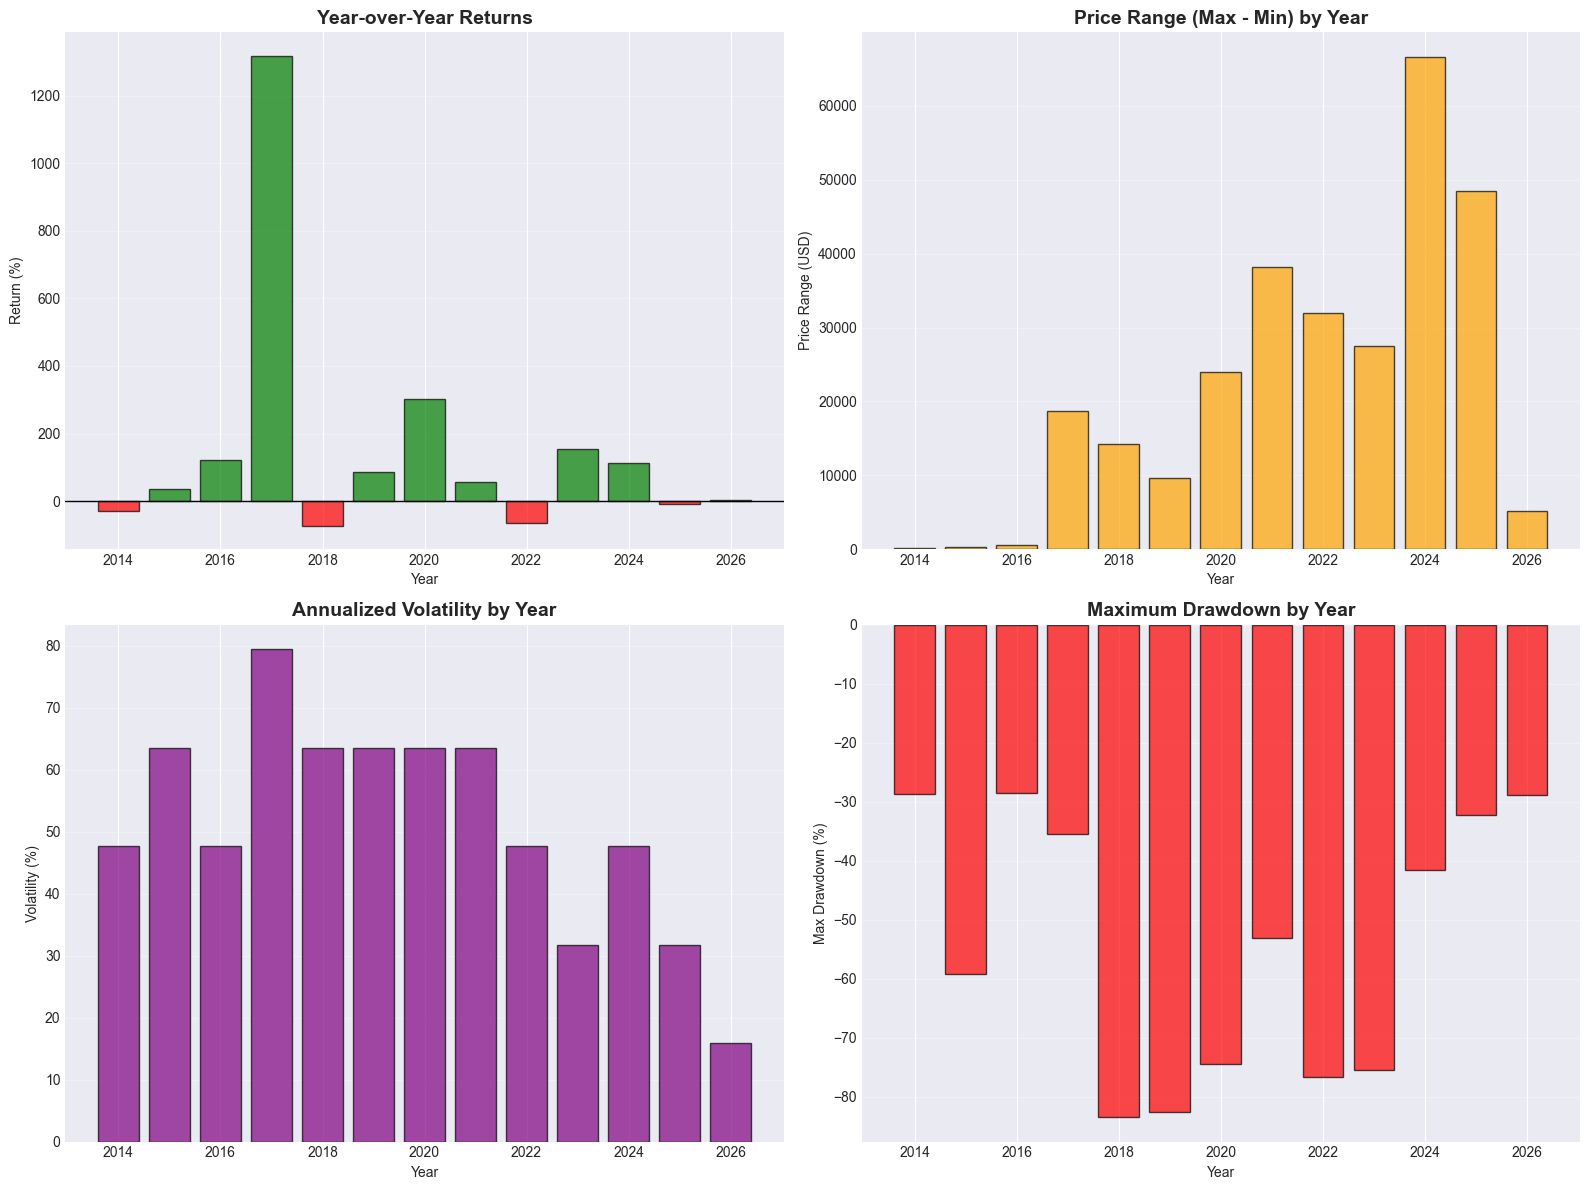

In [16]:
# Cell 16: Year-over-Year Performance Analysis

yearly_stats = df.groupby('Year').agg({
    'Close': ['first', 'last', 'min', 'max'],
    'Returns': ['mean', 'std', 'count'],
    'Volume': 'mean'
}).round(2)

yearly_stats.columns = ['Start_Price', 'End_Price', 'Min_Price', 'Max_Price', 
                        'Mean_Return', 'Std_Return', 'Trading_Days', 'Avg_Volume']

yearly_stats['YoY_Return'] = ((yearly_stats['End_Price'] / yearly_stats['Start_Price']) - 1) * 100
yearly_stats['Annualized_Vol'] = yearly_stats['Std_Return'] * np.sqrt(252) * 100
yearly_stats['Max_Drawdown'] = df.groupby('Year')['Drawdown_Pct'].min()

print("=" * 60)
print("YEAR-OVER-YEAR PERFORMANCE")
print("=" * 60)
print(yearly_stats)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Yearly returns
axes[0, 0].bar(yearly_stats.index, yearly_stats['YoY_Return'], 
               color=['green' if x > 0 else 'red' for x in yearly_stats['YoY_Return']],
               edgecolor='black', alpha=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0, 0].set_title('Year-over-Year Returns', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Return (%)')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Price range by year
price_ranges = yearly_stats['Max_Price'] - yearly_stats['Min_Price']
axes[0, 1].bar(yearly_stats.index, price_ranges, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Price Range (Max - Min) by Year', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Price Range (USD)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Volatility by year
axes[1, 0].bar(yearly_stats.index, yearly_stats['Annualized_Vol'], 
               color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Annualized Volatility by Year', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Volatility (%)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Maximum drawdown by year
axes[1, 1].bar(yearly_stats.index, yearly_stats['Max_Drawdown'], 
               color='red', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Maximum Drawdown by Year', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Max Drawdown (%)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Summary and Key Insights

In [17]:
# Cell 17: Executive Summary and Key Trading Insights

print("=" * 70)
print("BITCOIN PRICE ANALYSIS - EXECUTIVE SUMMARY")
print("=" * 70)

print("\n📊 DATASET OVERVIEW")
print("-" * 70)
print(f"  • Analysis Period: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"  • Total Trading Days: {len(df):,}")
print(f"  • Total Years Covered: {len(df) / 365.25:.2f}")

print("\n💰 PRICE PERFORMANCE")
print("-" * 70)
start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
total_return = ((end_price / start_price) - 1) * 100
annualized_return = ((end_price / start_price) ** (365.25 / len(df)) - 1) * 100
print(f"  • Starting Price: ${start_price:,.2f}")
print(f"  • Ending Price: ${end_price:,.2f}")
print(f"  • Total Return: {total_return:.2f}%")
print(f"  • Annualized Return: {annualized_return:.2f}%")
print(f"  • Highest Price: ${df['Close'].max():,.2f} ({df.loc[df['Close'].idxmax(), 'Date'].strftime('%Y-%m-%d')})")
print(f"  • Lowest Price: ${df['Close'].min():,.2f} ({df.loc[df['Close'].idxmin(), 'Date'].strftime('%Y-%m-%d')})")

print("\n📈 RISK METRICS")
print("-" * 70)
print(f"  • Annualized Volatility: {df['Returns'].std() * np.sqrt(252) * 100:.2f}%")
print(f"  • Sharpe Ratio: {overall_metrics['Sharpe Ratio']:.4f}")
print(f"  • Maximum Drawdown: {df['Drawdown_Pct'].min():.2f}%")
print(f"  • VaR (95%): {overall_metrics['VaR (95%)']:.2f}%")
print(f"  • CVaR (95%): {overall_metrics['CVaR (95%)']:.2f}%")
print(f"  • Calmar Ratio: {overall_metrics['Calmar Ratio']:.4f}")

print("\n📊 MARKET CHARACTERISTICS")
print("-" * 70)
print(f"  • Average Daily Return: {df['Returns'].mean() * 100:.4f}%")
print(f"  • Average Daily Volatility: {df['Returns'].std() * 100:.4f}%")
print(f"  • Return Skewness: {df['Returns'].skew():.4f}")
print(f"  • Return Kurtosis: {df['Returns'].kurtosis():.4f}")
print(f"  • Average Daily Volume: ${df['Volume'].mean() / 1e9:.2f} Billion")
print(f"  • Current Market Regime: {df['Regime'].iloc[-1]} Market")

print("\n🎯 TECHNICAL INDICATORS (Latest)")
print("-" * 70)
print(f"  • RSI: {df['RSI'].iloc[-1]:.2f}")
print(f"  • MACD: {df['MACD'].iloc[-1]:.2f}")
print(f"  • Price vs SMA 30: {((df['Close'].iloc[-1] / df['SMA_30'].iloc[-1]) - 1) * 100:.2f}%")
print(f"  • Price vs SMA 200: {((df['Close'].iloc[-1] / df['SMA_200'].iloc[-1]) - 1) * 100:.2f}%")

print("\n📅 SEASONAL PATTERNS")
print("-" * 70)
monthly_returns = df.groupby('Month')['Returns'].mean() * 100
dow_returns = df.groupby('DayOfWeek')['Returns'].mean() * 100
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(f"  • Best Month: {monthly_returns.idxmax()} ({monthly_returns.max():.3f}%)")
print(f"  • Worst Month: {monthly_returns.idxmin()} ({monthly_returns.min():.3f}%)")
print(f"  • Best Day: {dow_names[dow_returns.idxmax()]} ({dow_returns.max():.3f}%)")
print(f"  • Worst Day: {dow_names[dow_returns.idxmin()]} ({dow_returns.min():.3f}%)")

print("\n💡 KEY TRADING INSIGHTS")
print("-" * 70)
print("  1. Bitcoin has shown exceptional long-term growth with high volatility")
print("  2. Returns distribution shows significant fat tails (non-normal)")
print("  3. Volume patterns correlate with price movements and volatility")
print("  4. Market regime changes (Bull/Bear) are identifiable via moving averages")
print("  5. Seasonal patterns exist but are less pronounced than traditional assets")
print("  6. Technical indicators (RSI, MACD) provide useful market signals")
print("  7. Risk management is crucial given high drawdowns and volatility")

print("\n" + "=" * 70)
print("Analysis Complete ✓")
print("=" * 70)

BITCOIN PRICE ANALYSIS - EXECUTIVE SUMMARY

📊 DATASET OVERVIEW
----------------------------------------------------------------------
  • Analysis Period: 2014-09-17 to 2026-01-10
  • Total Trading Days: 4,134
  • Total Years Covered: 11.32

💰 PRICE PERFORMANCE
----------------------------------------------------------------------
  • Starting Price: $457.33
  • Ending Price: $90,386.65
  • Total Return: 19663.81%
  • Annualized Return: 59.53%
  • Highest Price: $124,752.53 (2025-10-06)
  • Lowest Price: $178.10 (2015-01-14)

📈 RISK METRICS
----------------------------------------------------------------------
  • Annualized Volatility: 55.79%
  • Sharpe Ratio: 0.8591
  • Maximum Drawdown: -83.40%
  • VaR (95%): -5.32%
  • CVaR (95%): -8.21%
  • Calmar Ratio: 0.5747

📊 MARKET CHARACTERISTICS
----------------------------------------------------------------------
  • Average Daily Return: 0.1902%
  • Average Daily Volatility: 3.5143%
  • Return Skewness: -0.1011
  • Return Kurtosis: 7.89